# Notebook 06 — Clean RF Population (Fresh Run)

Complete rerun from raw data with all methodology improvements.

## Methodology
- **Ridge regression** (GCV, per-container batch) — unchanged
- **Multistart fitting** (`n_random_starts=15`, TRF solver) — guards against local minima
- **Polarity fix** — m=0 map pre-flipped so dominant blob is always positive before fitting
- **Smoothing** — `smooth_sigma=0.75` applied consistently to all three models
- **Model selection** — `classify_rf_order` stores R² for m=0, m=1, m=2 per neuron; ΔR² used for triage
- **Orientation** — φ from lobe geometry (m=1); θ from envelope (m=0); theta_hybrid = preferred column

## Triage thresholds (empirically validated in 05e/05f)
| | Auto-accept | Manual review | Auto-reject → m=0 |
|---|---|---|---|
| **m=1** | ΔR²>0.15 AND R²≥0.45 | 0.05≤ΔR²≤0.15 OR ΔR²>0.15 but R²<0.45 | ΔR²<0.05 |
| **m=2** | ΔR²>0.10 | 0.05≤ΔR²≤0.10 | ΔR²<0.05 |

## Manual review display
7 panels per neuron: **Raw RF** | m=1 σ=0.75 | m=1 σ=1.0 | m=1 σ=1.5 | m=2 σ=0.75 | m=2 σ=1.0 | m=2 σ=1.5 | m=0

Higher-σ panels are visual aid only — all stored fits and ΔR² values use σ=0.75.

## Output
`outputs/rf_params/v3/` — fresh directory, no cached data from previous runs.


In [1]:
import sys, os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import pearsonr, circstd, mannwhitneyu
from scipy.spatial.distance import pdist, squareform
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import RidgeCV, Ridge
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

sys.path.insert(0, os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study/src'))
from rf_analysis.sparse_noise import (
    classify_rf_order,
    fit_rf_by_order,
    estimate_phi_from_lobes,
    _build_design_matrix,
    _pixel_size,
    _LAMBDA_GRID,
    gaussian_deriv_m0,
    gaussian_deriv_m1,
    gaussian_deriv_m2,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9})
print('Imports OK')


Imports OK


In [7]:
# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
base_dir  = Path(os.path.expanduser('~/dev/neuroscience/v1-dimensionality-study'))
cache_dir = base_dir / 'data' / 'cache'
lists_dir = base_dir / 'data' / 'experiment_lists'
v3_dir    = base_dir / 'outputs' / 'rf_params' / 'v3'
v3_dir.mkdir(parents=True, exist_ok=True)

JUDGEMENT_CSV = v3_dir / 'manual_judgements.csv'
FINAL_CSV     = v3_dir / 'rf_params_v3_final.csv'

boc = BrainObservatoryCache(manifest_file=str(cache_dir / 'manifest.json'))

batch_df       = pd.read_csv(lists_dir / 'all_l23_excitatory_experiments.csv')
verify_df      = pd.read_csv(lists_dir / 'downloaded_all_l23_excitatory_experiments.csv')
downloaded     = set(verify_df[verify_df['exists']]['experiment_id'].tolist())
container_meta = pd.read_csv(lists_dir / 'container_neuron_counts.csv')
complete_ids   = set(container_meta['container_id'].tolist())

session_c = batch_df[
    batch_df['session_type'].str.contains('C') &
    batch_df['id'].isin(downloaded) &
    batch_df['experiment_container_id'].isin(complete_ids)
].copy()
container_to_exp = dict(zip(session_c['experiment_container_id'], session_c['id']))
print(f'Containers: {len(container_to_exp)}')

# ---------------------------------------------------------------------------
# Methodology parameters — all in one place
# ---------------------------------------------------------------------------
SMOOTH_SIGMA   = 0.75   # smoothing applied to signed RF map before all fits
N_STARTS       = 15     # random initialisations per order (in addition to moment-based)
QC_R2_MIN      = 0.30   # minimum best-model R² to retain a neuron at all

# Triage thresholds
M1_AUTO_ACCEPT_DELTA = 0.15   # ΔR²(m1 vs m0) threshold for auto-accept
M1_AUTO_ACCEPT_R2    = 0.45   # minimum absolute R² for auto-accept (quality gate)
M1_AUTO_REJECT_DELTA = 0.05   # ΔR²(m1 vs m0) below this → auto m=0
M2_AUTO_ACCEPT_DELTA = 0.20   # ΔR²(m2 vs m0) threshold for auto-accept
M2_AUTO_REJECT_DELTA = 0.1   # ΔR²(m2 vs m0) below this → auto m=0

print('Parameters set.')
print(f'  SMOOTH_SIGMA={SMOOTH_SIGMA}  N_STARTS={N_STARTS}  QC_R2_MIN={QC_R2_MIN}')
print(f'  m=1: auto-accept ΔR²>{M1_AUTO_ACCEPT_DELTA} AND R²≥{M1_AUTO_ACCEPT_R2}')
print(f'       auto-reject  ΔR²<{M1_AUTO_REJECT_DELTA}')
print(f'  m=2: auto-accept ΔR²>{M2_AUTO_ACCEPT_DELTA}')
print(f'       auto-reject  ΔR²<{M2_AUTO_REJECT_DELTA}')


Containers: 17
Parameters set.
  SMOOTH_SIGMA=0.75  N_STARTS=15  QC_R2_MIN=0.3
  m=1: auto-accept ΔR²>0.15 AND R²≥0.45
       auto-reject  ΔR²<0.05
  m=2: auto-accept ΔR²>0.2
       auto-reject  ΔR²<0.1


In [3]:
# ---------------------------------------------------------------------------
# Container-level ridge regression → raw RF maps
# One NWB read + one ridge solve per container.
# Returns {cell_id: (rf_map_2d, pix_size_deg)}
# ---------------------------------------------------------------------------
def batch_get_rf_maps(dataset, requested_ids,
                       n_lags=8, response_delay=4, response_window=5):
    exp_cells = list(dataset.get_cell_specimen_ids())
    req_set   = set(int(c) for c in requested_ids)
    valid_ids = [c for c in exp_cells if c in req_set]
    if not valid_ids:
        raise ValueError('No requested cell_ids found.')

    stim_name = next((s for s in dataset.list_stimuli() if 'sparse_noise' in s), None)
    if not stim_name:
        raise ValueError('No sparse noise stimulus.')

    stim_table = dataset.get_stimulus_table(stim_name)
    tr         = dataset.get_locally_sparse_noise_stimulus_template(stimulus=stim_name)
    template   = tr[0] if isinstance(tr, tuple) else tr
    n_tf, grid_h, grid_w = template.shape
    on_val, off_val = int(template.max()), int(template.min())
    pix             = _pixel_size(stim_name)

    starts        = stim_table['start'].values.astype(int)
    frame_indices = stim_table['frame'].values.astype(int)

    _, all_dff    = dataset.get_dff_traces(cell_specimen_ids=valid_ids)
    n_cells, n_tp = all_dff.shape

    X = _build_design_matrix(template, frame_indices, on_val, off_val,
                              grid_h, grid_w, n_lags)

    win_idx  = (starts + response_delay)[:, None] + np.arange(response_window)
    in_bnds  = (win_idx >= 0) & (win_idx < n_tp)
    win_safe = np.clip(win_idx, 0, n_tp - 1)
    dff_wins = all_dff[:, win_safe]
    dff_wins[:, ~in_bnds] = np.nan
    Y = np.nanmean(dff_wins, axis=2).T
    Y = np.where(np.isnan(Y), 0.0, Y).astype(np.float64)

    frame_valid  = (frame_indices >= 0) & (frame_indices < n_tf)
    X_fit, Y_fit = X[frame_valid].astype(np.float64), Y[frame_valid]
    if X_fit.shape[0] < 20:
        raise ValueError('Too few valid presentations.')

    try:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None,
                      fit_intercept=True, alpha_per_target=True)
        rcv.fit(X_fit, Y_fit)
        W = np.atleast_2d(rcv.coef_)
    except TypeError:
        rcv = RidgeCV(alphas=_LAMBDA_GRID, cv=None, fit_intercept=True)
        rcv.fit(X_fit, Y_fit.mean(axis=1, keepdims=True))
        r = Ridge(alpha=float(rcv.alpha_), fit_intercept=True)
        r.fit(X_fit, Y_fit)
        W = np.atleast_2d(r.coef_)

    rf_out = {}
    for i, cid in enumerate(valid_ids):
        strf     = W[i].reshape(n_lags, grid_h, grid_w)
        best_lag = int(np.argmax([np.abs(strf[l]).max() for l in range(n_lags)]))
        rf_out[cid] = (strf[best_lag], pix)
    return rf_out

print('batch_get_rf_maps defined.')


batch_get_rf_maps defined.


In [4]:
# ---------------------------------------------------------------------------
# Full batch run — resumable (skips containers already saved to v3_dir)
#
# For each container:
#   1. Load NWB, solve ridge for all neurons (one read/solve per container)
#   2. Per neuron: classify_rf_order(m=0,1,2) with multistart + polarity fix
#   3. Save per-container CSV with R² for all three orders
#
# Expected: ~3-5 min per container
# ---------------------------------------------------------------------------
t_start = time.time()

for row_i, exp_row in session_c.iterrows():
    container_id = int(exp_row['experiment_container_id'])
    exp_id       = exp_row['id']
    cre_line     = exp_row['cre_line']
    depth        = exp_row['imaging_depth']

    out_file = v3_dir / f'container_{container_id}.csv'
    if out_file.exists():
        n_cached = len(pd.read_csv(out_file))
        print(f'  [SKIP] {container_id}: {n_cached} neurons cached')
        continue

    print(f'[{row_i+1}/{len(session_c)}] {container_id} | {cre_line} | {depth}μm',
          end=' ... ', flush=True)
    t0 = time.time()

    try:
        dataset  = boc.get_ophys_experiment_data(exp_id)
        cell_ids = list(dataset.get_cell_specimen_ids())
        rf_cache = batch_get_rf_maps(dataset, cell_ids)
    except Exception as e:
        print(f'FAIL (load): {e}')
        continue

    rows = []
    for cid in cell_ids:
        if cid not in rf_cache:
            continue
        rf_map, pix = rf_cache[cid]
        rf_on  = np.maximum( rf_map, 0.0)
        rf_off = np.maximum(-rf_map, 0.0)

        try:
            best_m, best_p, best_q, all_res = classify_rf_order(
                rf_on, rf_off,
                pixel_size_deg   = pix,
                smooth_sigma     = SMOOTH_SIGMA,
                delta_r2_threshold = 0.0,   # store raw best; triage done later
                n_random_starts  = N_STARTS,
                seed             = cid,     # reproducible
            )

            if best_q['r_squared'] < QC_R2_MIN:
                continue

            rows.append({
                'cell_id':            cid,
                'container_id':       container_id,
                'cre_line':           cre_line,
                'depth_um':           depth,
                # Best-model parameters
                'derivative_order':   best_m,
                'sigma':              best_p['sigma'],
                'theta':              best_p['theta'],
                'kappa':              best_p['kappa'],
                'x0':                 best_p['x0'],
                'y0':                 best_p['y0'],
                'sigma_x':            best_p['sigma_x'],
                'sigma_y':            best_p['sigma_y'],
                'amplitude':          best_p['amplitude'],
                'dominant_subfield':  best_p['dominant_subfield'],
                'phi':                best_p['phi'],
                'phi_confidence':     best_p['phi_confidence'],
                'theta_hybrid':       best_p['theta_hybrid'],
                # Fit quality
                'r_squared':          best_q['r_squared'],
                'rmse':               best_q['rmse'],
                'aic':                best_q['aic'],
                # R² for each order (critical for triage)
                'r2_m0':              all_res[0]['quality']['r_squared'],
                'r2_m1':              all_res[1]['quality']['r_squared'],
                'r2_m2':              all_res[2]['quality']['r_squared'],
                'delta_r2_m1_vs_m0':  (all_res[1]['quality']['r_squared']
                                        - all_res[0]['quality']['r_squared']),
                'delta_r2_m2_vs_m0':  (all_res[2]['quality']['r_squared']
                                        - all_res[0]['quality']['r_squared']),
                # Multistart diagnostics
                'n_starts_ok':        best_p.get('n_starts_succeeded', np.nan),
                'r2_improvement':     best_p.get('r2_improvement', np.nan),
            })
        except Exception as e:
            warnings.warn(f'Cell {cid}: {e}')

    if rows:
        pd.DataFrame(rows).to_csv(out_file, index=False)
        print(f'{len(rows)} neurons  ({time.time()-t0:.0f}s)')
    else:
        print('no neurons passed QC')

print(f'\nTotal: {(time.time()-t_start)/60:.1f} min')


[1/17] 650389885 | Slc17a7-IRES2-Cre | 175μm ... 33 neurons  (535s)
[11/17] 511510670 | Cux2-CreERT2 | 175μm ... 53 neurons  (266s)
[22/17] 511507650 | Cux2-CreERT2 | 175μm ... 64 neurons  (332s)
[24/17] 652842570 | Slc17a7-IRES2-Cre | 175μm ... 77 neurons  (308s)
[27/17] 511510650 | Cux2-CreERT2 | 175μm ... 17 neurons  (149s)
[28/17] 653125128 | Slc17a7-IRES2-Cre | 175μm ... 90 neurons  (2049s)
[29/17] 511509529 | Cux2-CreERT2 | 175μm ... 45 neurons  (348s)
[33/17] 661732156 | Slc17a7-IRES2-Cre | 175μm ... 125 neurons  (335s)
[35/17] 511510718 | Cux2-CreERT2 | 175μm ... 44 neurons  (364s)
[36/17] 666589599 | Slc17a7-IRES2-Cre | 175μm ... 36 neurons  (222s)
[37/17] 688678764 | Slc17a7-IRES2-Cre | 205μm ... 130 neurons  (521s)
[38/17] 701412138 | Cux2-CreERT2 | 175μm ... 37 neurons  (255s)
[42/17] 682734790 | Slc17a7-IRES2-Cre | 205μm ... 55 neurons  (362s)
[43/17] 680156909 | Slc17a7-IRES2-Cre | 175μm ... 71 neurons  (548s)
[44/17] 661437138 | Slc17a7-IRES2-Cre | 175μm ... 53 neurons  

In [5]:
# ---------------------------------------------------------------------------
# Load all per-container CSVs into one dataframe
# ---------------------------------------------------------------------------
csv_files = sorted(v3_dir.glob('container_*.csv'))
print(f'Found {len(csv_files)} container files')

all_df = pd.concat(
    [pd.read_csv(f) for f in csv_files],
    ignore_index=True
)
num_cols = ['sigma','theta','kappa','r_squared','rmse','aic',
            'sigma_x','sigma_y','x0','y0','phi','phi_confidence',
            'theta_hybrid','r2_m0','r2_m1','r2_m2',
            'delta_r2_m1_vs_m0','delta_r2_m2_vs_m0']
for c in num_cols:
    if c in all_df.columns:
        all_df[c] = pd.to_numeric(all_df[c], errors='coerce')

all_df['log_sigma'] = np.log10(all_df['sigma'])
all_df['log_kappa'] = np.log(all_df['kappa'])

print(f'Total neurons (R²≥{QC_R2_MIN}): {len(all_df):,}')
print(f'Containers: {all_df["container_id"].nunique()}')
print(f'\nRaw derivative_order breakdown:')
print(all_df['derivative_order'].value_counts().sort_index())
print(f'\nΔR²(m1 vs m0) percentiles:')
print(all_df['delta_r2_m1_vs_m0'].describe(percentiles=[.05,.25,.5,.75,.90,.95]).round(3))
print(f'\nΔR²(m2 vs m0) percentiles:')
print(all_df['delta_r2_m2_vs_m0'].describe(percentiles=[.05,.25,.5,.75,.90,.95]).round(3))


Found 17 container files
Total neurons (R²≥0.3): 1,017
Containers: 17

Raw derivative_order breakdown:
0    706
1    125
2    186
Name: derivative_order, dtype: int64

ΔR²(m1 vs m0) percentiles:
count    1017.000
mean       -0.087
std         0.111
min        -0.414
5%         -0.283
25%        -0.155
50%        -0.077
75%        -0.016
90%         0.036
95%         0.093
max         0.296
Name: delta_r2_m1_vs_m0, dtype: float64

ΔR²(m2 vs m0) percentiles:
count    1017.000
mean       -0.047
std         0.082
min        -0.513
5%         -0.177
25%        -0.098
50%        -0.040
75%         0.003
90%         0.045
95%         0.078
max         0.315
Name: delta_r2_m2_vs_m0, dtype: float64


In [8]:
# ---------------------------------------------------------------------------
# Triage — assign each neuron to auto-accept, manual-review, or auto-reject
#
# Applied to ALL neurons with derivative_order==1 or ==2 (not just raw winner).
# m=0 neurons are untouched — they go straight to final population.
# ---------------------------------------------------------------------------

# --- m=1 candidates: neurons where m=1 might beat m=0 ---
# We triage based on delta_r2_m1_vs_m0 regardless of which order 'won' automatically
# (the automated winner used delta_r2_threshold=0.0 so some m=1s may be questionable)

m1_cand = all_df.copy()  # every neuron is a m=1 candidate (need to check delta)

# For clarity, work with: any neuron where r2_m1 - r2_m0 > 0 (has any m=1 signal)
# but triage into bins:

def triage_m1(row):
    d = row['delta_r2_m1_vs_m0']
    if d < M1_AUTO_REJECT_DELTA:
        return 'auto_reject'
    elif d > M1_AUTO_ACCEPT_DELTA and row['r2_m1'] >= M1_AUTO_ACCEPT_R2:
        return 'auto_accept'
    else:
        return 'review'

def triage_m2(row):
    d = row['delta_r2_m2_vs_m0']
    if d < M2_AUTO_REJECT_DELTA:
        return 'auto_reject'
    elif d > M2_AUTO_ACCEPT_DELTA:
        return 'auto_accept'
    else:
        return 'review'

all_df['triage_m1'] = all_df.apply(triage_m1, axis=1)
all_df['triage_m2'] = all_df.apply(triage_m2, axis=1)

# Neurons that need manual review = either m=1 OR m=2 review bucket
review_m1 = all_df[all_df['triage_m1'] == 'review'].copy()
review_m2 = all_df[
    (all_df['triage_m2'] == 'review') &
    (all_df['triage_m1'] != 'review')   # don't double-count
].copy()

# Combined review queue (sorted by delta descending = most promising first)
review_all = pd.concat([
    review_m1.assign(_review_for='m1'),
    review_m2.assign(_review_for='m2'),
], ignore_index=True).sort_values('delta_r2_m1_vs_m0', ascending=False).reset_index(drop=True)

print('='*60)
print('TRIAGE SUMMARY')
print('='*60)
print(f'\nm=1 triage (n={len(all_df)} neurons):')
print(all_df['triage_m1'].value_counts())
print(f'\nm=2 triage (n={len(all_df)} neurons):')
print(all_df['triage_m2'].value_counts())
print(f'\nManual review queue: {len(review_all)} neurons')
print(f'  m=1 borderline: {len(review_m1)}')
print(f'  m=2 borderline (not already in m=1 queue): {len(review_m2)}')


TRIAGE SUMMARY

m=1 triage (n=1017 neurons):
auto_reject    930
review          78
auto_accept      9
Name: triage_m1, dtype: int64

m=2 triage (n=1017 neurons):
auto_reject    986
review          29
auto_accept      2
Name: triage_m2, dtype: int64

Manual review queue: 86 neurons
  m=1 borderline: 78
  m=2 borderline (not already in m=1 queue): 8


In [9]:
# ---------------------------------------------------------------------------
# Load RF maps for manual review neurons only
# Containers already reviewed in prior sessions are cached in dataset_cache.
# ---------------------------------------------------------------------------
rf_map_cache  = {}
dataset_cache = {}

by_container = review_all.groupby('container_id')['cell_id'].apply(list).to_dict()
print(f'Loading {len(review_all)} review neurons across {len(by_container)} containers')

t_start = time.time()
for i, (cid_c, cids) in enumerate(by_container.items()):
    missing = [c for c in cids if c not in rf_map_cache]
    if not missing:
        continue
    if cid_c not in container_to_exp:
        print(f'  {cid_c}: not in session_c — skip')
        continue
    print(f'  [{i+1}/{len(by_container)}] {cid_c} ({len(missing)} neurons)...',
          end=' ', flush=True)
    try:
        if cid_c not in dataset_cache:
            dataset_cache[cid_c] = boc.get_ophys_experiment_data(
                container_to_exp[cid_c])
        rf_map_cache.update(batch_get_rf_maps(dataset_cache[cid_c], missing))
        print(f'OK ({time.time()-t_start:.0f}s)')
    except Exception as e:
        print(f'FAIL: {e}')

review_df = review_all[review_all['cell_id'].isin(rf_map_cache)].reset_index(drop=True)
print(f'\n{len(review_df)} neurons ready for review')

# Load or initialise judgement store
if JUDGEMENT_CSV.exists():
    judged_df  = pd.read_csv(JUDGEMENT_CSV)
    judged_ids = set(judged_df['cell_id'].tolist())
    print(f'Loaded {len(judged_df)} existing judgements')
else:
    judged_df  = pd.DataFrame(columns=['cell_id', 'm_final', 'note'])
    judged_ids = set()
    print('Fresh judgement store.')

def _first_unjudged(start=0):
    for i in range(start, len(review_df)):
        if int(review_df.iloc[i]['cell_id']) not in judged_ids:
            return i
    return len(review_df) - 1

if 'REV_IDX' not in dir():
    REV_IDX = _first_unjudged()
remaining = sum(c not in judged_ids for c in review_df['cell_id'])
print(f'Remaining: {remaining}  |  Starting at index: {REV_IDX}')


Loading 86 review neurons across 16 containers
  [1/16] 511507650 (4 neurons)... OK (112s)
  [2/16] 511509529 (5 neurons)... OK (169s)
  [3/16] 511510650 (3 neurons)... OK (233s)
  [4/16] 511510670 (9 neurons)... OK (295s)
  [5/16] 511510718 (3 neurons)... OK (351s)
  [6/16] 511510736 (1 neurons)... OK (403s)
  [7/16] 511510855 (7 neurons)... OK (464s)
  [8/16] 650389885 (6 neurons)... OK (516s)
  [9/16] 652842570 (6 neurons)... OK (569s)
  [10/16] 653125128 (11 neurons)... OK (619s)
  [11/16] 661437138 (1 neurons)... OK (670s)
  [12/16] 661732156 (8 neurons)... OK (722s)
  [13/16] 666589599 (2 neurons)... OK (777s)
  [14/16] 680156909 (3 neurons)... OK (827s)
  [15/16] 682734790 (4 neurons)... OK (874s)
  [16/16] 688678764 (13 neurons)... OK (924s)

86 neurons ready for review
Fresh judgement store.
Remaining: 86  |  Starting at index: 0


In [10]:
# ---------------------------------------------------------------------------
# Fitting helpers for multi-sigma display
# All stored fits use SMOOTH_SIGMA=0.75.
# Higher-sigma panels are visual aid only — decision is always σ=0.75.
# ---------------------------------------------------------------------------
_MODEL_FNS = {0: gaussian_deriv_m0, 1: gaussian_deriv_m1, 2: gaussian_deriv_m2}

def fit_for_display(rf_map, pix, smooth_sigma, m, seed=None):
    """Fit order m at given smooth_sigma. Returns (r_squared, fitted_map)."""
    rf_on  = np.maximum( rf_map, 0.0)
    rf_off = np.maximum(-rf_map, 0.0)
    try:
        p, q = fit_rf_by_order(
            rf_on, rf_off, m=m,
            pixel_size_deg=pix,
            smooth_sigma=smooth_sigma,
            n_random_starts=N_STARTS,
            seed=seed,
        )
        grid_h, grid_w = rf_map.shape
        Yg, Xg = np.mgrid[0:grid_h, 0:grid_w].astype(float)
        su = p['sigma_x'] / pix
        sv = p['sigma_y'] / pix
        x0 = p['x0']     / pix
        y0 = p['y0']     / pix
        th = np.deg2rad(p['theta'])
        fitted = _MODEL_FNS[m]((Xg, Yg), p['amplitude'], x0, y0, su, sv, th, 0.0)
        return float(q['r_squared']), fitted.reshape(grid_h, grid_w)
    except Exception:
        return np.nan, None


def plot_review(cid, rf_map, pix, row_info):
    """
    7-panel review plot:
    Raw RF | m=1 σ=0.75 [★] | m=1 σ=1.0 | m=1 σ=1.5 | m=2 σ=0.75 [★] | m=2 σ=1.0 | m=2 σ=1.5 | m=0

    ★ = decision panels (σ=0.75 only)
    """
    rng = np.random.default_rng(cid)

    # Fit all panels
    panels = {}
    for m in [0, 1, 2]:
        for sig in [0.75, 1.0, 1.5]:
            s = int(rng.integers(0, 2**31))
            panels[(m, sig)] = fit_for_display(rf_map, pix, sig, m, seed=s)

    r2_m0   = panels[(0, 0.75)][0]
    r2_m1   = {sig: panels[(1, sig)][0] for sig in [0.75, 1.0, 1.5]}
    r2_m2   = {sig: panels[(2, sig)][0] for sig in [0.75, 1.0, 1.5]}
    d1      = r2_m1[0.75] - r2_m0
    d2      = r2_m2[0.75] - r2_m0

    cre    = str(row_info.get('cre_line', ''))[:18]
    depth  = row_info.get('depth_um', '')
    review_for = row_info.get('_review_for', '?')

    # Suggestion
    if d1 > M1_AUTO_ACCEPT_DELTA and r2_m1[0.75] >= M1_AUTO_ACCEPT_R2:
        suggest = 1
    elif d2 > M2_AUTO_ACCEPT_DELTA:
        suggest = 2
    else:
        suggest = 0

    fig = plt.figure(figsize=(32, 4.0))
    gs  = gridspec.GridSpec(1, 8, figure=fig, wspace=0.03)

    title_str = (
        f'Cell {cid}  |  {cre}  {depth}μm  |  review_for={review_for}  '
        f'|  ΔR²(m1)={d1:+.3f}  ΔR²(m2)={d2:+.3f}  '
        f'|  R²: m0={r2_m0:.3f}  m1={r2_m1[0.75]:.3f}  m2={r2_m2[0.75]:.3f}  '
        f'|  → Suggest m={suggest}'
    )
    fig.suptitle(title_str, fontsize=8.5, fontweight='bold')

    vmax = np.nanpercentile(np.abs(rf_map), 98)
    imkw = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                aspect='auto', origin='lower', interpolation='nearest')

    # Panel 0: Raw RF
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(rf_map, **imkw)
    ax.set_title('Raw RF', fontsize=8)
    ax.axis('off')

    # Panels 1-3: m=1 at three sigmas
    for col_i, sig in enumerate([0.75, 1.0, 1.5], start=1):
        ax = fig.add_subplot(gs[0, col_i])
        r2, fitted = panels[(1, sig)]
        if fitted is not None:
            ax.imshow(fitted, **imkw)
        else:
            ax.set_facecolor('#2c2c2c')
            ax.text(0.5, 0.5, 'fail', color='w', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8)
        is_dec = (sig == 0.75)
        delta  = r2 - r2_m0 if not np.isnan(r2) else np.nan
        ax.set_title(
            f'm=1  σ={sig}{"  ←DEC" if is_dec else "  [vis]"}\n'
            f'R²={r2:.3f}  Δ={delta:+.3f}',
            fontsize=7.5,
            fontweight='bold' if is_dec else 'normal',
            color='#2980b9' if is_dec else '#888'
        )
        ax.axis('off')

    # Panels 4-6: m=2 at three sigmas
    for col_i, sig in enumerate([0.75, 1.0, 1.5], start=4):
        ax = fig.add_subplot(gs[0, col_i])
        r2, fitted = panels[(2, sig)]
        if fitted is not None:
            ax.imshow(fitted, **imkw)
        else:
            ax.set_facecolor('#2c2c2c')
            ax.text(0.5, 0.5, 'fail', color='w', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8)
        is_dec = (sig == 0.75)
        delta  = r2 - r2_m0 if not np.isnan(r2) else np.nan
        ax.set_title(
            f'm=2  σ={sig}{"  ←DEC" if is_dec else "  [vis]"}\n'
            f'R²={r2:.3f}  Δ={delta:+.3f}',
            fontsize=7.5,
            fontweight='bold' if is_dec else 'normal',
            color='#e67e22' if is_dec else '#888'
        )
        ax.axis('off')

    # Panel 7: m=0 reference
    ax = fig.add_subplot(gs[0, 7])
    _, f0 = panels[(0, 0.75)]
    if f0 is not None:
        ax.imshow(f0, **imkw)
    else:
        ax.set_facecolor('#2c2c2c')
    ax.set_title(f'm=0  σ=0.75\nR²={r2_m0:.3f}  (ref)', fontsize=7.5, color='#27ae60')
    ax.axis('off')

    return fig, suggest

print('Display helpers defined.')


Display helpers defined.


--- 86/86 ---  cell 517406400  review_for=m2  ΔR²(m1)=-0.054  ΔR²(m2)=+0.109


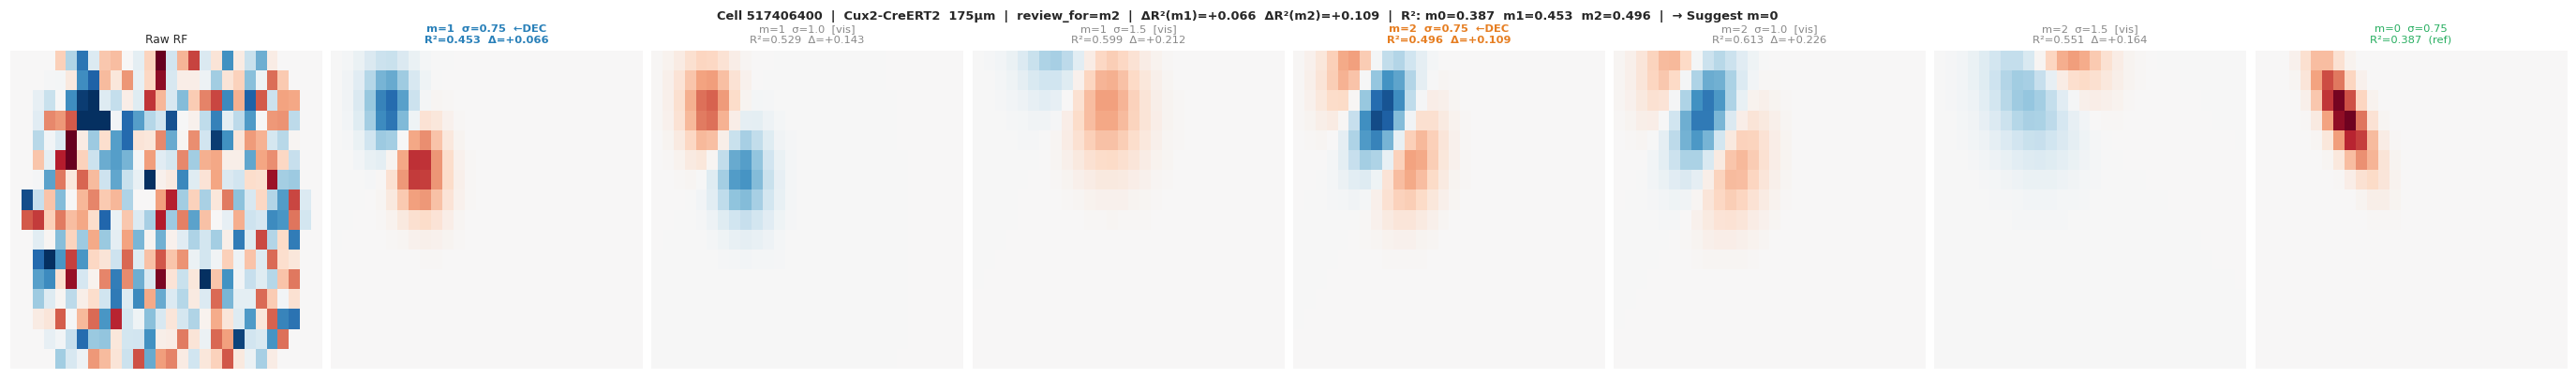

Suggested: m=0  (set M_FINAL in RECORD cell)


In [182]:
# ---------------------------------------------------------------------------
# SHOW CELL — re-run to advance
# ---------------------------------------------------------------------------
row     = review_df.iloc[REV_IDX]
cid     = int(row['cell_id'])
rf_map, pix = rf_map_cache[cid]

print(f'--- {REV_IDX+1}/{len(review_df)} ---  cell {cid}  '
      f'review_for={row["_review_for"]}  '
      f'ΔR²(m1)={row["delta_r2_m1_vs_m0"]:+.3f}  '
      f'ΔR²(m2)={row["delta_r2_m2_vs_m0"]:+.3f}')

if cid in judged_ids:
    prev = judged_df[judged_df['cell_id'] == cid].iloc[-1]
    print(f'↩ Previously: m={prev["m_final"]}  note="{prev["note"]}"')

fig, _suggest = plot_review(cid, rf_map, pix, row.to_dict())
plt.tight_layout()
plt.show()
print(f'Suggested: m={_suggest}  (set M_FINAL in RECORD cell)')


In [183]:
# ---------------------------------------------------------------------------
# RECORD CELL — set M_FINAL, then run; then re-run SHOW CELL
# ---------------------------------------------------------------------------
M_FINAL = _suggest   # <- override to 0, 1, or 2
NOTE    = ''         # <- optional note

row = review_df.iloc[REV_IDX]
cid = int(row['cell_id'])

judged_df  = pd.concat(
    [judged_df[judged_df['cell_id'] != cid],
     pd.DataFrame([{'cell_id': cid, 'm_final': M_FINAL, 'note': NOTE}])],
    ignore_index=True
)
judged_ids = set(judged_df['cell_id'].tolist())
judged_df.to_csv(JUDGEMENT_CSV, index=False)

done = sum(c in judged_ids for c in review_df['cell_id'])
print(f'✓ cell {cid}  m={M_FINAL}  ({done}/{len(review_df)} done, '
      f'{len(review_df)-done} remaining)')

REV_IDX = _first_unjudged(REV_IDX + 1)
print(f'Next: {REV_IDX}  → re-run SHOW CELL')


✓ cell 517406400  m=0  (86/86 done, 0 remaining)
Next: 85  → re-run SHOW CELL


In [184]:
# ---------------------------------------------------------------------------
# MERGE — build final population
#
# Priority:
#   1. Manual judgement (from this notebook only)
#   2. Auto-accept / auto-reject from triage thresholds
#   3. derivative_order from classify_rf_order (for m=0 neurons)
#
# m=0 neurons never need review — they're always accepted as m=0.
# ---------------------------------------------------------------------------

# Check completeness
remaining = sum(c not in judged_ids for c in review_df['cell_id'])
if remaining > 0:
    print(f'⚠ {remaining} review neurons still unjudged — merge anyway.')
else:
    print('✓ All review neurons judged.')

# Build m_final column
def resolve_m_final(row):
    cid = int(row['cell_id'])
    # 1. Manual judgement takes priority
    if cid in judged_ids:
        return int(judged_df.loc[judged_df['cell_id']==cid, 'm_final'].iloc[0])
    # 2. Auto rules
    if row['triage_m1'] == 'auto_accept':
        return 1
    if row['triage_m2'] == 'auto_accept':
        return 2
    # 3. Everything else → m=0
    return 0

all_df['m_final'] = all_df.apply(resolve_m_final, axis=1)

print(f'\nm_final breakdown:')
print(all_df['m_final'].value_counts().sort_index())

m0 = all_df[all_df['m_final'] == 0]
m1 = all_df[all_df['m_final'] == 1]
m2 = all_df[all_df['m_final'] == 2]

print(f'\nm=1 summary (n={len(m1)}):')
if len(m1):
    print(m1[['sigma','kappa','r_squared']].describe().round(3))

print(f'\nm=2 summary (n={len(m2)}):')
if len(m2):
    print(m2[['sigma','kappa','r_squared']].describe().round(3))

all_df.to_csv(FINAL_CSV, index=False)
print(f'\nSaved → {FINAL_CSV}')


✓ All review neurons judged.

m_final breakdown:
0    992
1     25
Name: m_final, dtype: int64

m=1 summary (n=25):
        sigma   kappa  r_squared
count  25.000  25.000     25.000
mean    7.862   1.466      0.494
std     1.684   0.429      0.087
min     5.368   1.000      0.328
25%     6.780   1.234      0.445
50%     7.652   1.304      0.482
75%     8.417   1.679      0.547
max    12.549   2.455      0.723

m=2 summary (n=0):

Saved → /home/dmescherina/dev/neuroscience/v1-dimensionality-study/outputs/rf_params/v3/rf_params_v3_final.csv


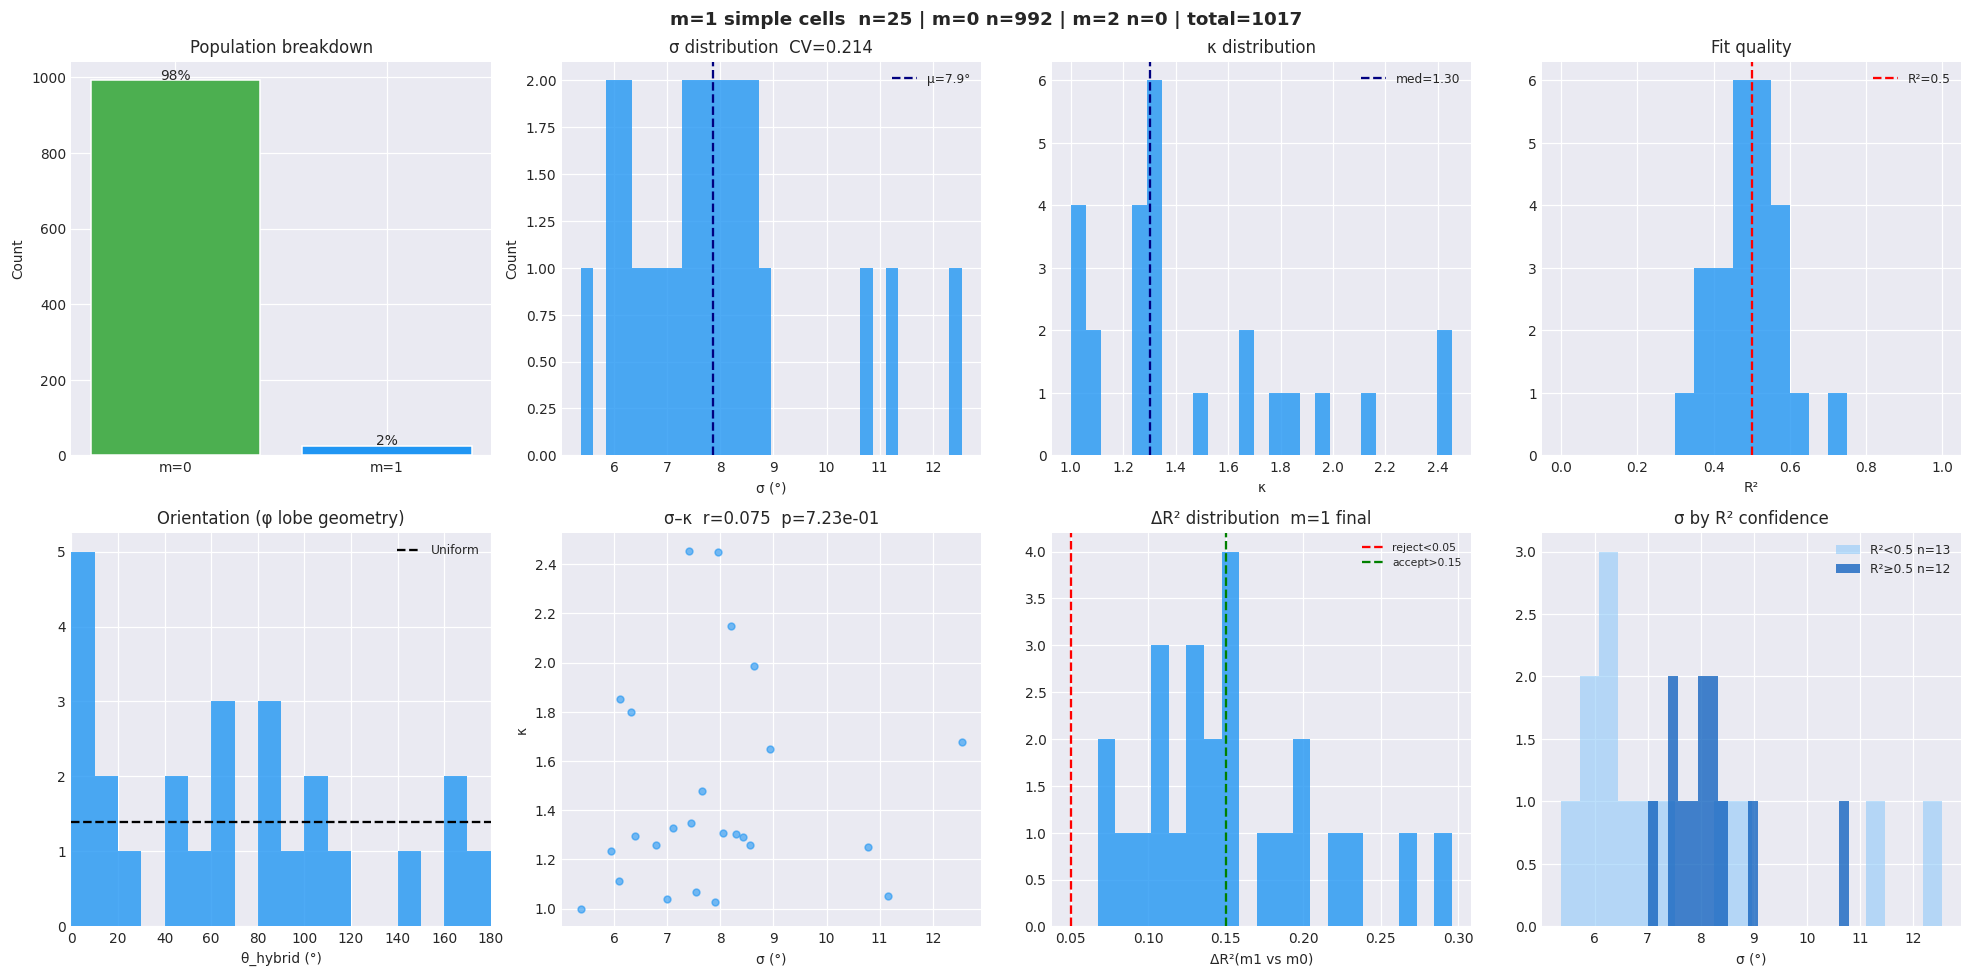


Final population summary:
  Total: 1017  |  m=0: 992  m=1: 25  m=2: 0
  m=1  σ mean=7.86°  κ med=1.30  R² mean=0.494


In [185]:
# ---------------------------------------------------------------------------
# Population overview — m=1 only (m=2 reported separately if n>5)
# ---------------------------------------------------------------------------
if len(m1) == 0:
    print('No m=1 neurons — skipping figures.')
else:
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(f'm=1 simple cells  n={len(m1)} | '
                 f'm=0 n={len(m0)} | m=2 n={len(m2)} | total={len(all_df)}',
                 fontsize=12, fontweight='bold')

    # Population bar
    ax = axes[0,0]
    counts = all_df['m_final'].value_counts().sort_index()
    ax.bar([f'm={m}' for m in counts.index], counts.values,
           color=['#4CAF50','#2196F3','#FF9800'][:len(counts)],
           edgecolor='white')
    for i,(m,c) in enumerate(counts.items()):
        ax.text(i, c+3, f'{100*c/len(all_df):.0f}%', ha='center', fontsize=9)
    ax.set_ylabel('Count'); ax.set_title('Population breakdown')

    # σ distribution
    ax = axes[0,1]
    ax.hist(m1['sigma'].dropna(), bins=30, color='#2196F3', alpha=0.8)
    ax.axvline(m1['sigma'].mean(), color='navy', ls='--', lw=1.5,
               label=f'μ={m1["sigma"].mean():.1f}°')
    ax.set_xlabel('σ (°)'); ax.set_ylabel('Count')
    ax.set_title(f'σ distribution  CV={m1["sigma"].std()/m1["sigma"].mean():.3f}')
    ax.legend(fontsize=8)

    # κ distribution
    ax = axes[0,2]
    ax.hist(m1['kappa'].dropna(), bins=25, color='#2196F3', alpha=0.8)
    ax.axvline(m1['kappa'].median(), color='navy', ls='--', lw=1.5,
               label=f'med={m1["kappa"].median():.2f}')
    ax.set_xlabel('κ'); ax.set_title('κ distribution'); ax.legend(fontsize=8)

    # R² distribution
    ax = axes[0,3]
    ax.hist(m1['r_squared'].dropna(), bins=20, range=(0,1),
            color='#2196F3', alpha=0.8)
    ax.axvline(0.5, color='red', ls='--', lw=1.5, label='R²=0.5')
    ax.set_xlabel('R²'); ax.set_title('Fit quality')
    ax.legend(fontsize=8)

    # θ_hybrid orientation
    ax = axes[1,0]
    ax.hist(m1['theta_hybrid'].dropna(), bins=18, range=(0,180),
            color='#2196F3', alpha=0.8)
    ax.axhline(len(m1)/18, color='k', ls='--', lw=1.5, label='Uniform')
    ax.set_xlabel('θ_hybrid (°)'); ax.set_title('Orientation (φ lobe geometry)')
    ax.set_xlim(0,180); ax.legend(fontsize=8)

    # σ–κ scatter
    ax = axes[1,1]
    ax.scatter(m1['sigma'], m1['kappa'], s=20, alpha=0.6, color='#2196F3')
    if m1[['sigma','kappa']].dropna().shape[0] > 2:
        r,p = pearsonr(m1['sigma'].dropna(),
                       m1.loc[m1['sigma'].notna(),'kappa'])
        ax.set_title(f'σ–κ  r={r:.3f}  p={p:.2e}')
    ax.set_xlabel('σ (°)'); ax.set_ylabel('κ')

    # ΔR²(m1 vs m0) distribution for final m=1
    ax = axes[1,2]
    ax.hist(m1['delta_r2_m1_vs_m0'].dropna(), bins=20, color='#2196F3', alpha=0.8)
    ax.axvline(M1_AUTO_REJECT_DELTA, color='red', ls='--', lw=1.5,
               label=f'reject<{M1_AUTO_REJECT_DELTA}')
    ax.axvline(M1_AUTO_ACCEPT_DELTA, color='green', ls='--', lw=1.5,
               label=f'accept>{M1_AUTO_ACCEPT_DELTA}')
    ax.set_xlabel('ΔR²(m1 vs m0)'); ax.set_title('ΔR² distribution  m=1 final')
    ax.legend(fontsize=7)

    # R² by confidence tier
    ax = axes[1,3]
    hi = m1[m1['r_squared'] >= 0.5]
    lo = m1[m1['r_squared'] <  0.5]
    ax.hist(lo['sigma'].dropna(), bins=20, alpha=0.6, color='#90CAF9',
            label=f'R²<0.5 n={len(lo)}')
    ax.hist(hi['sigma'].dropna(), bins=20, alpha=0.8, color='#1565C0',
            label=f'R²≥0.5 n={len(hi)}')
    ax.set_xlabel('σ (°)'); ax.set_title('σ by R² confidence')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(v3_dir / 'fig_population_overview.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nFinal population summary:')
    print(f'  Total: {len(all_df)}  |  m=0: {len(m0)}  m=1: {len(m1)}  m=2: {len(m2)}')
    print(f'  m=1  σ mean={m1["sigma"].mean():.2f}°  κ med={m1["kappa"].median():.2f}  '
          f'R² mean={m1["r_squared"].mean():.3f}')
    if len(m2):
        print(f'  m=2  σ mean={m2["sigma"].mean():.2f}°  κ med={m2["kappa"].median():.2f}  '
              f'R² mean={m2["r_squared"].mean():.3f}')
